In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import joblib


def predict_house_price(
    area,                      # Diện tích (m²)
    floor_number,              # Số tầng
    bedroom_number,            # Số phòng ngủ
    street_in_front_of_house,  # Độ rộng đường trước nhà (m)
    width,                     # Chiều rộng mặt tiền nhà (m)
    city,                      # 1 = Hà Nội, 0 = TP.HCM
    district,                  # 1 = Nội thành, 0 = Ngoại thành
    house_type,                # 1 = Mặt tiền, 0 = Trong hẻm

    is_car_pack=0,
    is_kitchen=0,
    is_terrace=0,
    is_dinning_room=0,

    model_path='/content/drive/MyDrive/Colab Notebooks/Khai pha DL TLU/Cuối kỳ/Best model/house_price_xgb_package.pkl'
):

    # =========================================================
    # LOAD PACKAGE
    # =========================================================

    package = joblib.load(model_path)

    model = package['model']

    # Lấy metrics nếu có
    metrics = package.get('metrics', {})

    # =========================================================
    # INPUT DATA
    # =========================================================

    input_raw = {
        'area': np.log1p(area),
        'floor_number': np.log1p(floor_number),
        'bedroom_number': np.log1p(bedroom_number),

        'is_dinning_room': is_dinning_room,
        'is_kitchen': is_kitchen,
        'is_terrace': is_terrace,
        'is_car_pack': is_car_pack,

        'type': house_type,

        'street_in_front_of_house': np.log1p(street_in_front_of_house),
        'width': np.log1p(width),

        'city': city,
        'district': district
    }

    input_df = pd.DataFrame([input_raw])

    # =========================================================
    # PREDICT
    # =========================================================

    log_price = model.predict(input_df)[0]

    # Inverse log-transform
    price_billion = np.expm1(log_price)

    # =========================================================
    # PRINT RESULT
    # =========================================================

    print("=" * 50)
    print("           KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ")
    print("=" * 50)

    print(f"Diện tích              : {area} m²")
    print(f"Số tầng                : {floor_number}")
    print(f"Số phòng ngủ           : {bedroom_number}")
    print(f"Độ rộng đường          : {street_in_front_of_house} m")
    print(f"Chiều rộng mặt tiền    : {width} m")

    print(f"Thành phố              : {'Hà Nội' if city == 1 else 'TP.HCM'}")
    print(f"Khu vực                : {'Nội thành' if district == 1 else 'Ngoại thành'}")
    print(f"Loại nhà               : {'Mặt tiền' if house_type == 1 else 'Trong hẻm'}")

    print("-" * 50)

    print(f"Giá dự đoán            : {price_billion:.2f} tỷ đồng")

    # =========================================================
    # MODEL METRICS
    # =========================================================

    if metrics:

        print("-" * 50)
        print("HIỆU SUẤT MÔ HÌNH XGBOOST")

        if 'r2' in metrics:
            print(f"R² Score               : {metrics['r2']:.4f}")

        if 'rmse' in metrics:
            print(f"RMSE                   : {metrics['rmse']:.4f}")

        if 'mae' in metrics:
            print(f"MAE                    : {metrics['mae']:.4f}")

        if 'cv_mae' in metrics:
            print(f"CV MAE                 : {metrics['cv_mae']:.4f}")

    print("=" * 50)

    return price_billion


# =========================================================
# EXAMPLE
# =========================================================

predict_house_price(
    area=50,
    floor_number=3,
    bedroom_number=3,
    street_in_front_of_house=4,
    width=4,

    city=1,          # Hà Nội
    district=1,      # Nội thành
    house_type=0,    # Trong hẻm

    is_car_pack=1
)

           KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ
Diện tích              : 50 m²
Số tầng                : 3
Số phòng ngủ           : 3
Độ rộng đường          : 4 m
Chiều rộng mặt tiền    : 4 m
Thành phố              : Hà Nội
Khu vực                : Nội thành
Loại nhà               : Trong hẻm
--------------------------------------------------
Giá dự đoán            : 7.37 tỷ đồng
--------------------------------------------------
HIỆU SUẤT MÔ HÌNH XGBOOST
RMSE                   : 0.2761
MAE                    : 0.1984
CV MAE                 : 0.1920


np.float32(7.3713245)

In [6]:
# =========================================================
# NHẬP THỦ CÔNG THÔNG TIN CĂN NHÀ
# =========================================================

print("=" * 50)
print("        NHẬP THÔNG TIN CĂN NHÀ")
print("=" * 50)

# ---------------------------------------------------------
# Thông tin cơ bản
# ---------------------------------------------------------

area = float(input("Diện tích (m²)                     : "))

floor_number = int(input("Số tầng                           : "))

bedroom_number = int(input("Số phòng ngủ                      : "))

street_in_front_of_house = float(
    input("Độ rộng đường trước nhà (m)      : ")
)

width = float(
    input("Chiều rộng mặt tiền nhà (m)      : ")
)

# ---------------------------------------------------------
# Thành phố
# ---------------------------------------------------------

print("\nTHÀNH PHỐ")
print("1 = Hà Nội")
print("0 = TP.HCM")

city = int(input("Nhập lựa chọn                     : "))

# ---------------------------------------------------------
# Khu vực
# ---------------------------------------------------------

print("\nKHU VỰC")
print("1 = Nội thành")
print("0 = Ngoại thành")

district = int(input("Nhập lựa chọn                     : "))

# ---------------------------------------------------------
# Loại nhà
# ---------------------------------------------------------

print("\nLOẠI NHÀ")
print("1 = Nhà mặt tiền")
print("0 = Nhà trong hẻm")

house_type = int(input("Nhập lựa chọn                     : "))

# ---------------------------------------------------------
# Tiện ích
# ---------------------------------------------------------

print("\nTIỆN ÍCH")
print("1 = Có")
print("0 = Không")

is_car_pack = int(
    input("Chỗ để xe ô tô                    : ")
)

is_kitchen = int(
    input("Có bếp                            : ")
)

is_terrace = int(
    input("Có sân thượng                     : ")
)

is_dinning_room = int(
    input("Có phòng ăn                       : ")
)

# =========================================================
# GỌI HÀM DỰ ĐOÁN
# =========================================================

predict_house_price(
    area=area,
    floor_number=floor_number,
    bedroom_number=bedroom_number,
    street_in_front_of_house=street_in_front_of_house,
    width=width,

    city=city,
    district=district,
    house_type=house_type,

    is_car_pack=is_car_pack,
    is_kitchen=is_kitchen,
    is_terrace=is_terrace,
    is_dinning_room=is_dinning_room
)

        NHẬP THÔNG TIN CĂN NHÀ
Diện tích (m²)                     : 50
Số tầng                           : 10
Số phòng ngủ                      : 12
Độ rộng đường trước nhà (m)      : 36
Chiều rộng mặt tiền nhà (m)      : 5

THÀNH PHỐ
1 = Hà Nội
0 = TP.HCM
Nhập lựa chọn                     : 1

KHU VỰC
1 = Nội thành
0 = Ngoại thành
Nhập lựa chọn                     : 1

LOẠI NHÀ
1 = Nhà mặt tiền
0 = Nhà trong hẻm
Nhập lựa chọn                     : 1

TIỆN ÍCH
1 = Có
0 = Không
Chỗ để xe ô tô                    : 1
Có bếp                            : 1
Có sân thượng                     : 1
Có phòng ăn                       : 1
           KẾT QUẢ DỰ ĐOÁN GIÁ NHÀ
Diện tích              : 50.0 m²
Số tầng                : 10
Số phòng ngủ           : 12
Độ rộng đường          : 36.0 m
Chiều rộng mặt tiền    : 5.0 m
Thành phố              : Hà Nội
Khu vực                : Nội thành
Loại nhà               : Mặt tiền
--------------------------------------------------
Giá dự đoán            : 7.

np.float32(7.857237)

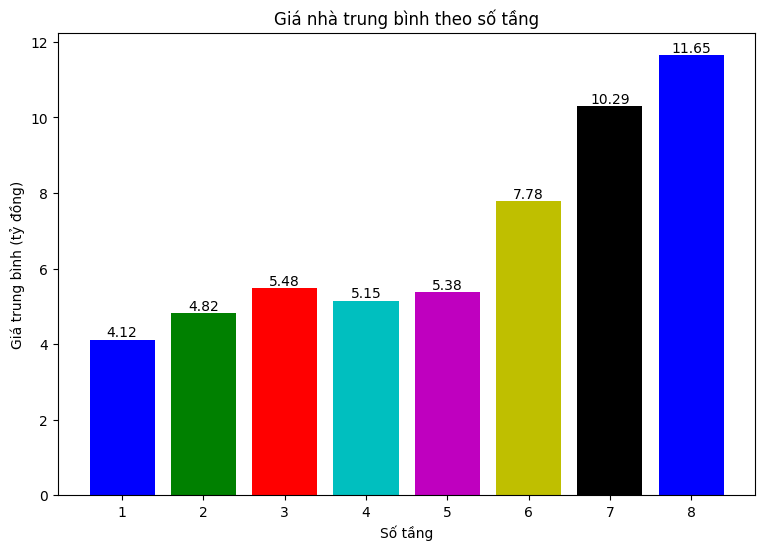

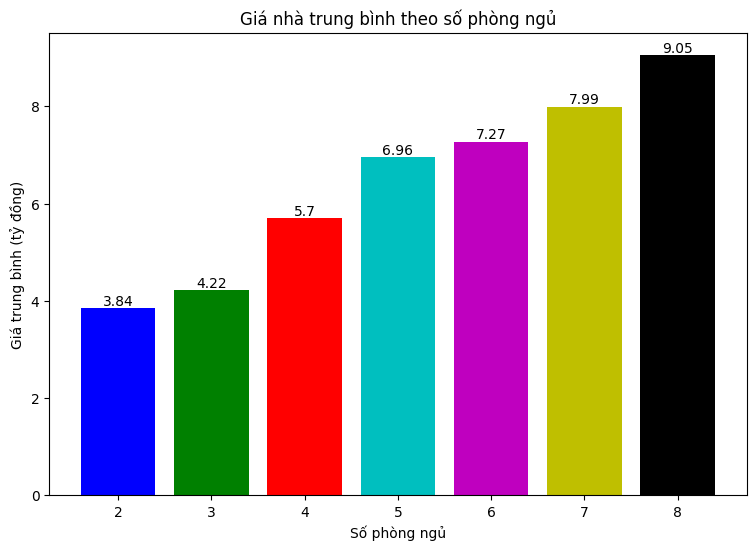

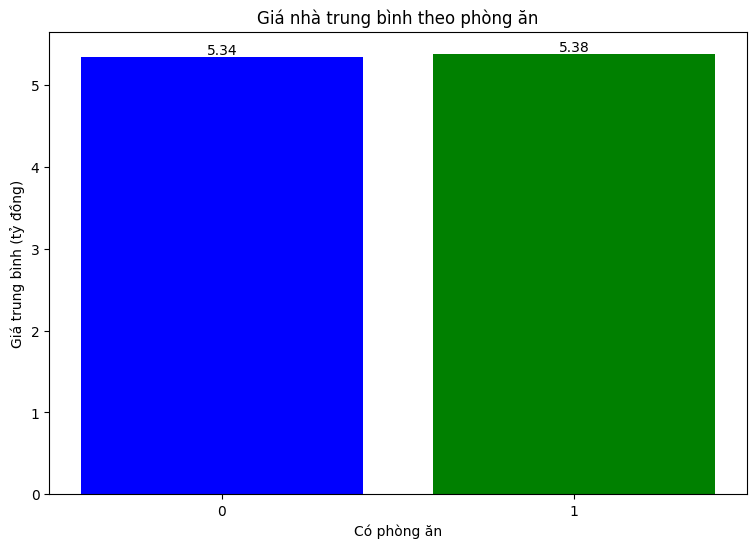

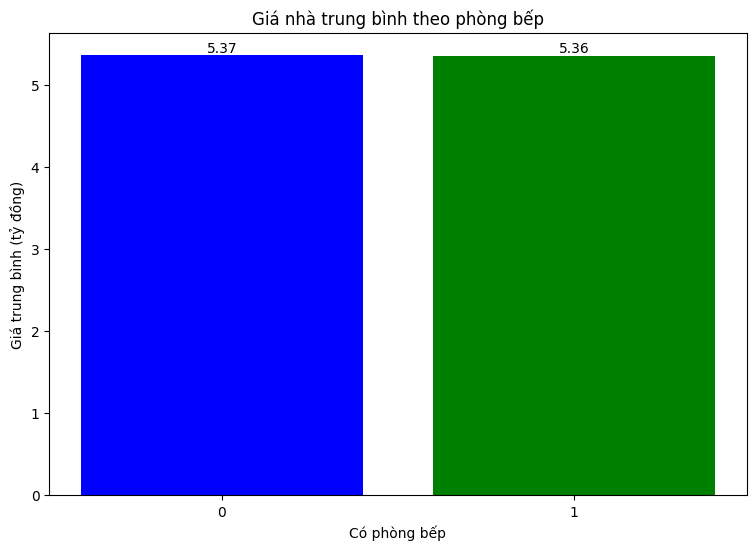

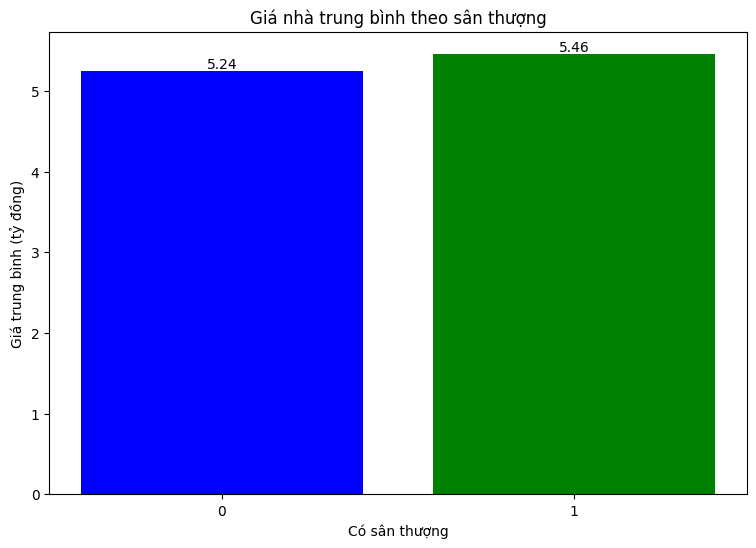

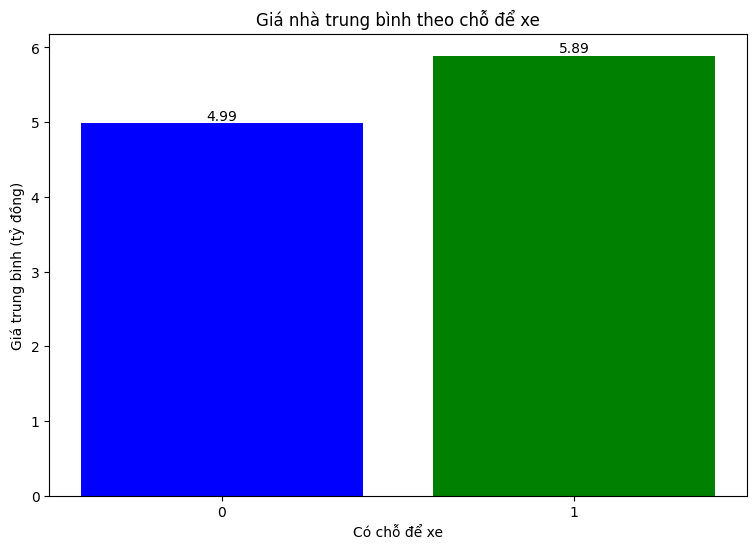

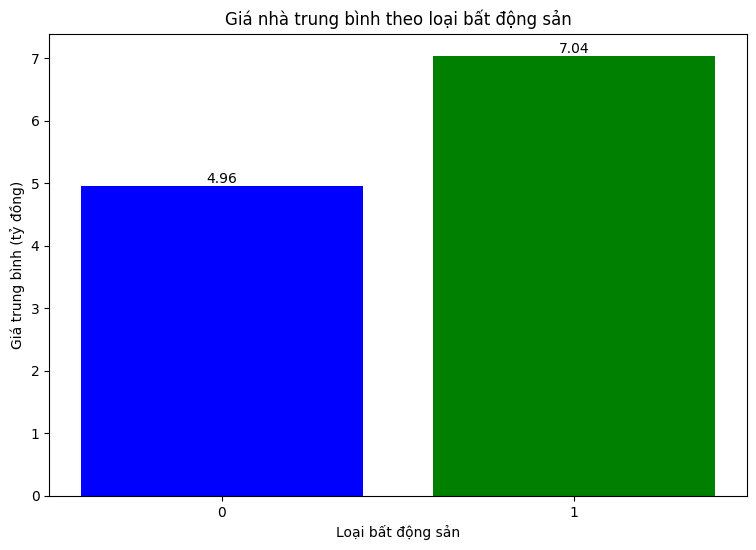

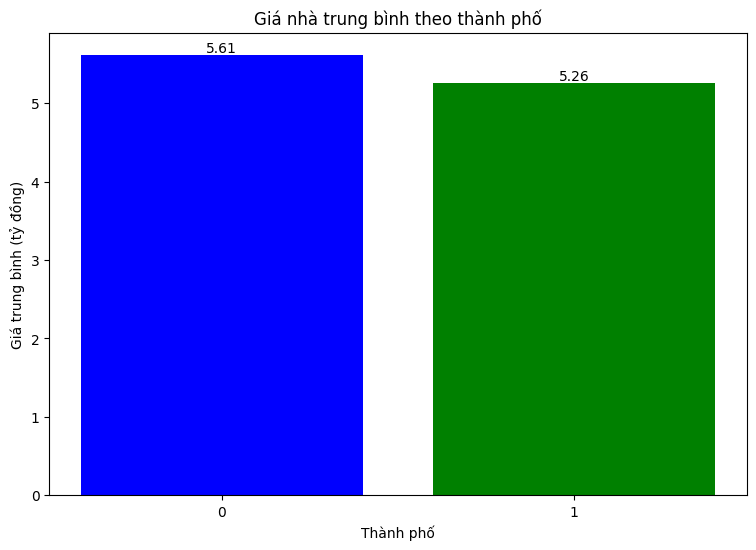

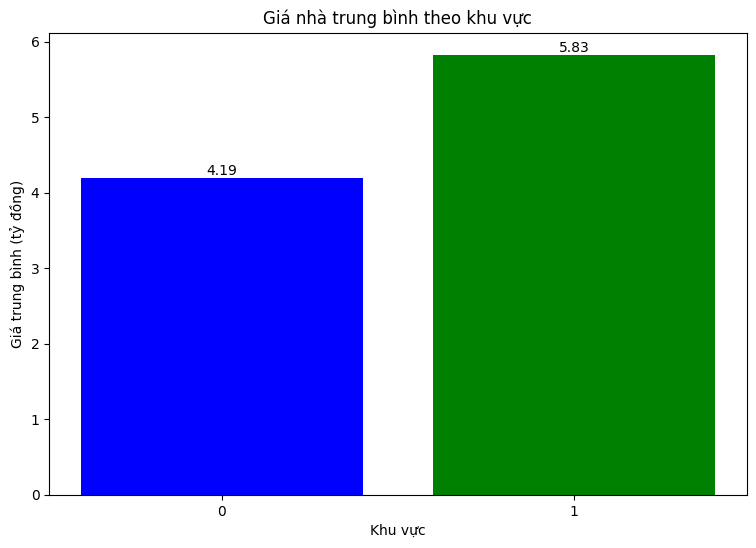

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Khai pha DL TLU/Cuối kỳ/Data btl datamining/clean_housepredict_data.csv')

feature_df = df.drop(
    columns=[
        'price',
        'area',
        'street_in_front_of_house',
        'width'
    ]
)

feature_names = feature_df.columns.tolist()

labels = [
    'Số tầng',
    'Số phòng ngủ',
    'Có phòng ăn',
    'Có phòng bếp',
    'Có sân thượng',
    'Có chỗ để xe',
    'Loại bất động sản',
    'Thành phố',
    'Khu vực'
]

titles = [
    'Giá nhà trung bình theo số tầng',
    'Giá nhà trung bình theo số phòng ngủ',
    'Giá nhà trung bình theo phòng ăn',
    'Giá nhà trung bình theo phòng bếp',
    'Giá nhà trung bình theo sân thượng',
    'Giá nhà trung bình theo chỗ để xe',
    'Giá nhà trung bình theo loại bất động sản',
    'Giá nhà trung bình theo thành phố',
    'Giá nhà trung bình theo khu vực'
]
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

for idx, col in enumerate(feature_names):
    # Tính mean theo từng nhóm (đang ở dạng log)
    grouped_data = (
        df.groupby(col)['price']
        .mean()
        .sort_index()
    )

    # Chuyển đổi x_values về số thực nếu là 'floor_number' hoặc 'bedroom_number'
    if col in ['floor_number', 'bedroom_number']:
        x_values = [str(int(round(np.expm1(float(val))))) for val in grouped_data.index]
    else:
        x_values = grouped_data.index.astype(str)

    # Chuyển đổi ngược từ log sang giá trị thực (tỷ đồng) cho trục Y
    y_values = np.expm1(grouped_data.values)

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        x_values,
        y_values,
        color=colors[:len(x_values)]
    )

    # Hiển thị giá trị trên đầu cột
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            round(y, 2),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xlabel(labels[idx])
    plt.ylabel('Giá trung bình (tỷ đồng)')
    plt.title(titles[idx])

    plt.xticks(rotation=0)
    plt.show()